/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Original Shape: (7129, 97)
After Cleaning: (7129, 96)
After Transpose: (96, 7129)
Duplicate genes found: 1466
After Duplicate Handling: (96, 5663)
Cancer Shape : (86, 5663)
Normal Shape : (10, 5663)

Using ALL genes without Welch T-Test...
Filtered Data Shape: (96, 5663)

Creating Disk-Based Covariance Matrices...
Covariance Shape: (5663, 5663)

Building Cancer Covariance Matrix...
Processed Cancer Rows 0 -> 1000
Processed Cancer Rows 1000 -> 2000
Processed Cancer Rows 2000 -> 3000
Processed Cancer Rows 3000 -> 4000
Processed Cancer Rows 4000 -> 5000
Processed Cancer Rows 5000 -> 5663

Building Normal Covariance Matrix...
Processed Normal Rows 0 -> 1000
Processed Normal Rows 1000 -> 2000
Processed Normal Rows 2000 -> 3000
Processed Normal Rows 3000 -> 4000
Processed Normal Rows 4000 -> 5000
Processed Normal Rows 5000 -> 5663

Covariance matrices stored on disk!

Running Partial Eigen Decomposition...
Genes : 5663
Scores: 5663

Top Important Genes:
           Gene     Score
5181       T

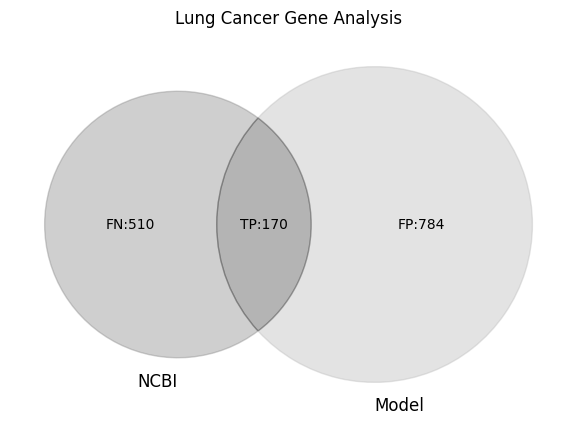

In [1]:
# LUNG CANCER GENE ANALYSIS
# LOW-RAM COVARIANCE EIGENVECTOR METHOD

# STEP 0: IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from scipy.sparse.linalg import eigsh

from matplotlib_venn import venn2

import ast
import os

# STEP 1: LOAD DATA

df = pd.read_excel(
    "/content/drive/MyDrive/gene_expression_data_for_Lung.xlsx"
)

print("Original Shape:", df.shape)

# STEP 2: CLEAN DATA

df.rename(columns={df.columns[0]: "GENE"}, inplace=True)
df["GENE"] = df["GENE"].astype(str).str.strip()
df = df[
    df["GENE"].notna() &
    (df["GENE"] != "") &
    (df["GENE"].str.upper() != "NULL")
]
df.set_index("GENE", inplace=True)

print("After Cleaning:", df.shape)

# STEP 3: TRANSPOSE

data = df.T

print("After Transpose:", data.shape)

# STEP 4: FIX DATA TYPES

data = data.apply(
    pd.to_numeric,
    errors='coerce'
).fillna(0)

data.columns = data.columns.astype(str)

# STEP 5: HANDLE DUPLICATES
# USING HIGHEST VALUE

if data.columns.duplicated().sum() > 0:

    print(
        "Duplicate genes found:",
        data.columns.duplicated().sum()
    )

    # Keep highest value among duplicates
    data = data.T.groupby(level=0).max().T

print("After Duplicate Handling:", data.shape)

# STEP 6: STANDARDIZATION

scaler = StandardScaler()

data_scaled = scaler.fit_transform(data).astype(np.float32)

data_scaled = pd.DataFrame(
    data_scaled,
    columns=data.columns
)

# STEP 7: SPLIT DATA

cancer_scaled = data_scaled.iloc[:86, :]
normal_scaled = data_scaled.iloc[86:, :]

print("Cancer Shape :", cancer_scaled.shape)
print("Normal Shape :", normal_scaled.shape)

# STEP 8: USE ALL GENES DIRECTLY

significant_genes = data.columns

filtered_data = data_scaled[
    significant_genes
]

filtered_cancer = filtered_data.iloc[:86, :]
filtered_normal = filtered_data.iloc[86:, :]

print(
    "Filtered Data Shape:",
    filtered_data.shape
)

# STEP 9: DISK-BASED COVARIANCE MATRICES

print("\nCreating Disk-Based Covariance Matrices...")

# CONVERT TO NUMPY

X_cancer = filtered_cancer.values.astype(np.float32)
X_normal = filtered_normal.values.astype(np.float32)

# MEAN CENTERING

X_cancer = X_cancer - X_cancer.mean(axis=0)
X_normal = X_normal - X_normal.mean(axis=0)

# SHAPES

n_samples_c, n_features = X_cancer.shape
n_samples_n, _ = X_normal.shape

print("Covariance Shape:", (n_features, n_features))

# CREATE MEMMAP FILES

cov_cancer_path = "cov_cancer.dat"
cov_normal_path = "cov_normal.dat"

cov_cancer = np.memmap(
    cov_cancer_path,
    dtype='float32',
    mode='w+',
    shape=(n_features, n_features)
)

cov_normal = np.memmap(
    cov_normal_path,
    dtype='float32',
    mode='w+',
    shape=(n_features, n_features)
)

# BLOCK SIZE

block_size = 1000

# CANCER COVARIANCE

print("\nBuilding Cancer Covariance Matrix...")

for i in range(0, n_features, block_size):

    i_end = min(i + block_size, n_features)

    Xi = X_cancer[:, i:i_end]

    for j in range(0, n_features, block_size):

        j_end = min(j + block_size, n_features)

        Xj = X_cancer[:, j:j_end]

        block_cov = (
            Xi.T @ Xj
        ) / (n_samples_c - 1)

        cov_cancer[i:i_end, j:j_end] = block_cov

    print(f"Processed Cancer Rows {i} -> {i_end}")

cov_cancer.flush()

# NORMAL COVARIANCE

print("\nBuilding Normal Covariance Matrix...")

for i in range(0, n_features, block_size):

    i_end = min(i + block_size, n_features)

    Xi = X_normal[:, i:i_end]

    for j in range(0, n_features, block_size):

        j_end = min(j + block_size, n_features)

        Xj = X_normal[:, j:j_end]

        block_cov = (
            Xi.T @ Xj
        ) / (n_samples_n - 1)

        cov_normal[i:i_end, j:j_end] = block_cov

    print(f"Processed Normal Rows {i} -> {i_end}")

cov_normal.flush()

print("\nCovariance matrices stored on disk!")

# STEP 10: PARTIAL EIGEN DECOMPOSITION

print("\nRunning Partial Eigen Decomposition...")

k = 5

eigvals_c, eigvecs_c = eigsh(
    cov_cancer,
    k=k,
    which='LM'
)

eigvals_n, eigvecs_n = eigsh(
    cov_normal,
    k=k,
    which='LM'
)

# STEP 11: SORT EIGENVECTORS

idx_c = np.argsort(eigvals_c)[::-1]
idx_n = np.argsort(eigvals_n)[::-1]

eigvals_c = eigvals_c[idx_c]
eigvecs_c = eigvecs_c[:, idx_c]

eigvals_n = eigvals_n[idx_n]
eigvecs_n = eigvecs_n[:, idx_n]

top_vecs_c = eigvecs_c
top_vecs_n = eigvecs_n

# STEP 12: SIGN ALIGNMENT

for i in range(k):

    if np.dot(
        top_vecs_c[:, i],
        top_vecs_n[:, i]
    ) < 0:

        top_vecs_n[:, i] = -top_vecs_n[:, i]

# STEP 13: GENE SCORING

score_cancer = np.mean(
    np.abs(top_vecs_c),
    axis=1
)

score_normal = np.mean(
    np.abs(top_vecs_n),
    axis=1
)

gene_scores = np.abs(
    score_cancer - score_normal
) / (
    np.abs(score_cancer) +
    np.abs(score_normal) +
    1e-8
)

genes = significant_genes

print("Genes :", len(genes))
print("Scores:", len(gene_scores))

assert len(genes) == len(gene_scores)

# STEP 14: IMPORTANCE TABLE

gene_importance = pd.DataFrame({
    "Gene": genes,
    "Score": gene_scores
})

gene_importance = gene_importance.sort_values(
    by="Score",
    ascending=False
)

print("\nTop Important Genes:")
print(gene_importance.head(20))

# STEP 15: SCORE STATISTICS

scores = gene_importance["Score"].values

print("\n===== SCORE STATISTICS =====")

print("Max Score :", np.max(scores))
print("Min Score :", np.min(scores))
print("Mean Score:", np.mean(scores))
print("STD Score :", np.std(scores))

# STEP 16: THRESHOLD SELECTION

threshold = 0.50

print(f"\nChosen Threshold: {threshold}")

selected_genes_df = gene_importance[
    gene_importance["Score"] >= threshold
]

selected_genes = set(
    selected_genes_df["Gene"]
)

print(
    "\nTotal Genes Above Threshold:",
    len(selected_genes)
)

print("\nTop Selected Genes:")
print(selected_genes_df.head(20))

# STEP 17: LOAD REFERENCE DATABASE

ref_file = "/content/drive/MyDrive/gene_alias_dict.txt"

with open(ref_file, "r") as f:

    content = f.read()

start = content.find("{")
end = content.rfind("}") + 1

gene_alias_dict = ast.literal_eval(
    content[start:end]
)

gene_alias_dict = {
    k.upper(): [a.upper() for a in v]
    for k, v in gene_alias_dict.items()
}

# STEP 18: CREATE ALIAS MAP

alias_to_main = {}

for main_gene, aliases in gene_alias_dict.items():

    for alias in aliases:

        alias_to_main[alias] = main_gene

# STEP 19: GENE MAPPING FUNCTION

def map_to_main(gene):

    gene = str(gene).upper()

    if gene in gene_alias_dict:
        return gene

    if gene in alias_to_main:
        return alias_to_main[gene]

    return gene

# STEP 20: VALIDATION

selected_genes_mapped = set(
    map_to_main(g)
    for g in selected_genes
)

reference_genes = set(
    gene_alias_dict.keys()
)

matched_genes = (
    selected_genes_mapped &
    reference_genes
)

unmatched_genes = (
    selected_genes_mapped -
    reference_genes
)

print("\n===== VALIDATION =====")

print(
    "Total Selected Genes:",
    len(selected_genes_mapped)
)

print(
    "Reference Genes:",
    len(reference_genes)
)

print(
    "Matched Genes:",
    len(matched_genes)
)

print(
    "Unmatched Genes:",
    len(unmatched_genes)
)

precision_validation = (
    len(matched_genes) /
    len(selected_genes_mapped)
    if len(selected_genes_mapped) > 0
    else 0
)

print(
    "Precision:",
    precision_validation
)

# STEP 21: DATASET-ONLY EVALUATION

all_genes = set(
    map_to_main(g)
    for g in genes
)

predicted_genes = selected_genes_mapped

known_genes = set(
    g for g in reference_genes
    if g in all_genes
)

print("Known Genes:", len(known_genes))

TP_genes = predicted_genes & known_genes

FP_genes = predicted_genes - known_genes

FN_genes = known_genes - predicted_genes

TN_genes = all_genes - (
    TP_genes |
    FP_genes |
    FN_genes
)

# STEP 22: METRICS

TP = len(TP_genes)
FP = len(FP_genes)
FN = len(FN_genes)
TN = len(TN_genes)

total_genes = len(all_genes)

accuracy = (
    (TP + TN) / total_genes
    if total_genes > 0 else 0
)

precision = (
    TP / (TP + FP)
    if (TP + FP) > 0 else 0
)

recall = (
    TP / (TP + FN)
    if (TP + FN) > 0 else 0
)

f1_score = (
    2 * precision * recall /
    (precision + recall + 1e-8)
)

print("\n===============================")
print(" DATASET-ONLY GENE EVALUATION")
print("===============================\n")

print(f"Total Genes : {total_genes}")

print(f"TP : {TP}")
print(f"FP : {FP}")
print(f"FN : {FN}")
print(f"TN : {TN}")

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1_score:.4f}")

# STEP 23: VENN DIAGRAM

plt.figure(figsize=(10, 5))

v = venn2(
    subsets=(FN, FP, TP),
    set_labels=("NCBI", "Model")
)

v.get_patch_by_id('10').set_color('#888888')
v.get_patch_by_id('01').set_color('#bbbbbb')
v.get_patch_by_id('11').set_color('#444444')

v.get_label_by_id('10').set_text(f"FN:{FN}")
v.get_label_by_id('01').set_text(f"FP:{FP}")
v.get_label_by_id('11').set_text(f"TP:{TP}")

plt.title("Lung Cancer Gene Analysis")

plt.show()


===== CLOSEST INTERSECTION =====
Threshold : 0.55
Accuracy  : 0.8004
Precision : 0.181
Recall    : 0.1853
F1 Score  : 0.1831


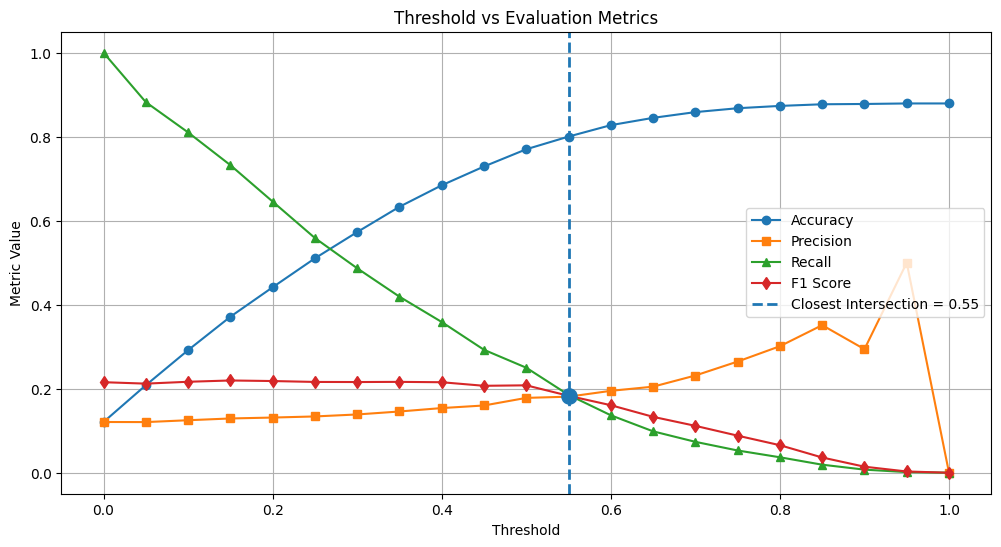

In [11]:
thresholds = np.arange(0, 1.01, 0.05)

accuracies = []
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:

    selected = set(
        gene_importance[
            gene_importance["Score"] >= threshold
        ]["Gene"]
    )

    predicted_genes = {
        map_to_main(g)
        for g in selected
    }

    TP_genes = predicted_genes & known_genes
    FP_genes = predicted_genes - known_genes
    FN_genes = known_genes - predicted_genes

    TN_genes = all_genes - (
        TP_genes |
        FP_genes |
        FN_genes
    )

    TP = len(TP_genes)
    FP = len(FP_genes)
    FN = len(FN_genes)
    TN = len(TN_genes)

    accuracy = (
        (TP + TN) /
        (TP + FP + FN + TN)
    )

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0 else 0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0 else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-8)
    )

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

# ==========================================
# FIND "MIDDLE INTERSECTION"
# ==========================================

best_idx = None
best_diff = float("inf")

for i in range(1, len(thresholds)-1):   # skip first and last

    diff = (
        abs(precisions[i] - recalls[i])
        + abs(precisions[i] - f1_scores[i])
        + abs(recalls[i] - f1_scores[i])
    )

    if diff < best_diff:
        best_diff = diff
        best_idx = i

intersection_threshold = thresholds[best_idx]

print("\n===== CLOSEST INTERSECTION =====")
print("Threshold :", intersection_threshold)
print("Accuracy  :", round(accuracies[best_idx], 4))
print("Precision :", round(precisions[best_idx], 4))
print("Recall    :", round(recalls[best_idx], 4))
print("F1 Score  :", round(f1_scores[best_idx], 4))

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    thresholds,
    accuracies,
    marker='o',
    label='Accuracy'
)

plt.plot(
    thresholds,
    precisions,
    marker='s',
    label='Precision'
)

plt.plot(
    thresholds,
    recalls,
    marker='^',
    label='Recall'
)

plt.plot(
    thresholds,
    f1_scores,
    marker='d',
    label='F1 Score'
)

# Vertical line at closest intersection

plt.axvline(
    x=intersection_threshold,
    linestyle='--',
    linewidth=2,
    label=f'Closest Intersection = {intersection_threshold:.2f}'
)

plt.scatter(
    intersection_threshold,
    f1_scores[best_idx],
    s=120,
    zorder=5
)

plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold vs Evaluation Metrics")

plt.grid(True)
plt.legend()

plt.show()

Original Shape: (22181, 57)
After Cleaning: (22181, 56)
After Transpose: (56, 22181)
Duplicate genes found: 7223
After Duplicate Handling: (56, 14958)
Normal Shape : (13, 14958)
Cancer Shape : (43, 14958)

Using ALL genes without Welch T-Test...
Filtered Data Shape: (56, 14958)

Creating Disk-Based Covariance Matrices...
Covariance Shape: (14958, 14958)

Building Cancer Covariance Matrix...
Processed Cancer Rows 0 -> 1000
Processed Cancer Rows 1000 -> 2000
Processed Cancer Rows 2000 -> 3000
Processed Cancer Rows 3000 -> 4000
Processed Cancer Rows 4000 -> 5000
Processed Cancer Rows 5000 -> 6000
Processed Cancer Rows 6000 -> 7000
Processed Cancer Rows 7000 -> 8000
Processed Cancer Rows 8000 -> 9000
Processed Cancer Rows 9000 -> 10000
Processed Cancer Rows 10000 -> 11000
Processed Cancer Rows 11000 -> 12000
Processed Cancer Rows 12000 -> 13000
Processed Cancer Rows 13000 -> 14000
Processed Cancer Rows 14000 -> 14958

Building Normal Covariance Matrix...
Processed Normal Rows 0 -> 1000
Pro

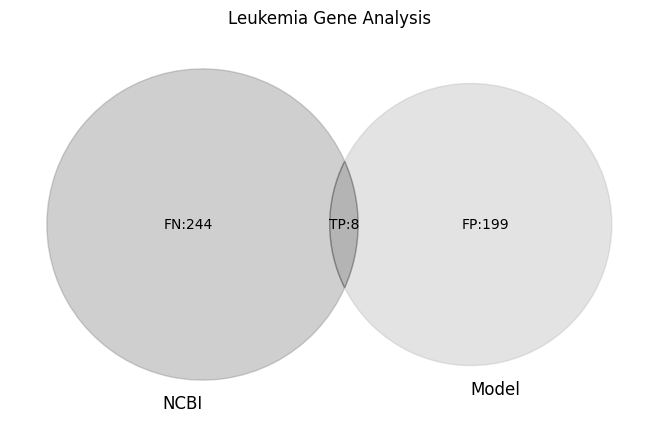

In [23]:
# LEUKEMIA GENE ANALYSIS
# LOW-RAM COVARIANCE EIGENVECTOR METHOD

# STEP 0: IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from scipy.sparse.linalg import eigsh

from matplotlib_venn import venn2

import ast
import os

# STEP 1: LOAD DATA

df = pd.read_excel(
    "/content/drive/MyDrive/leukemia.xlsx"
)

print("Original Shape:", df.shape)

# STEP 2: CLEAN DATA

df.rename(columns={df.columns[0]: "GENE"}, inplace=True)

df["GENE"] = df["GENE"].astype(str).str.strip()

df = df[
    df["GENE"].notna() &
    (df["GENE"] != "") &
    (df["GENE"].str.upper() != "NULL")
]

df.set_index("GENE", inplace=True)

print("After Cleaning:", df.shape)

# STEP 3: TRANSPOSE

data = df.T

print("After Transpose:", data.shape)

# STEP 4: FIX DATA TYPES

data = data.apply(
    pd.to_numeric,
    errors='coerce'
).fillna(0)

data.columns = data.columns.astype(str)

# STEP 5: HANDLE DUPLICATES
# USING HIGHEST VALUE

if data.columns.duplicated().sum() > 0:

    print(
        "Duplicate genes found:",
        data.columns.duplicated().sum()
    )

    # Keep highest value among duplicates
    data = data.T.groupby(level=0).max().T

print("After Duplicate Handling:", data.shape)

# STEP 6: STANDARDIZATION

scaler = StandardScaler()

data_scaled = scaler.fit_transform(data).astype(np.float32)

data_scaled = pd.DataFrame(
    data_scaled,
    columns=data.columns
)

# STEP 7: SPLIT DATA

# FIRST 13 = NORMAL
# REST = CANCER

normal_scaled = data_scaled.iloc[:13, :]
cancer_scaled = data_scaled.iloc[13:, :]

print("Normal Shape :", normal_scaled.shape)
print("Cancer Shape :", cancer_scaled.shape)

# STEP 8: USE ALL GENES DIRECTLY

significant_genes = data.columns

filtered_data = data_scaled[
    significant_genes
]

filtered_cancer = filtered_data.iloc[13:, :]
filtered_normal = filtered_data.iloc[:13, :]

print(
    "Filtered Data Shape:",
    filtered_data.shape
)

# STEP 9: DISK-BASED COVARIANCE MATRICES

print("\nCreating Disk-Based Covariance Matrices...")

# NUMPY CONVERSION

X_cancer = filtered_cancer.values.astype(np.float32)
X_normal = filtered_normal.values.astype(np.float32)

# MEAN CENTERING

X_cancer = X_cancer - X_cancer.mean(axis=0)
X_normal = X_normal - X_normal.mean(axis=0)

# SHAPES

n_samples_c, n_features = X_cancer.shape
n_samples_n, _ = X_normal.shape

print("Covariance Shape:", (n_features, n_features))

# MEMMAP FILES

cov_cancer_path = "cov_cancer.dat"
cov_normal_path = "cov_normal.dat"

cov_cancer = np.memmap(
    cov_cancer_path,
    dtype='float32',
    mode='w+',
    shape=(n_features, n_features)
)

cov_normal = np.memmap(
    cov_normal_path,
    dtype='float32',
    mode='w+',
    shape=(n_features, n_features)
)

# BLOCK SIZE
block_size = 1000

# BUILD CANCER COVARIANCE

print("\nBuilding Cancer Covariance Matrix...")

for i in range(0, n_features, block_size):

    i_end = min(i + block_size, n_features)

    Xi = X_cancer[:, i:i_end]

    for j in range(0, n_features, block_size):

        j_end = min(j + block_size, n_features)

        Xj = X_cancer[:, j:j_end]

        block_cov = (
            Xi.T @ Xj
        ) / (n_samples_c - 1)

        cov_cancer[i:i_end, j:j_end] = block_cov

    print(f"Processed Cancer Rows {i} -> {i_end}")

cov_cancer.flush()

# BUILD NORMAL COVARIANCE

print("\nBuilding Normal Covariance Matrix...")

for i in range(0, n_features, block_size):

    i_end = min(i + block_size, n_features)

    Xi = X_normal[:, i:i_end]

    for j in range(0, n_features, block_size):

        j_end = min(j + block_size, n_features)

        Xj = X_normal[:, j:j_end]

        block_cov = (
            Xi.T @ Xj
        ) / (n_samples_n - 1)

        cov_normal[i:i_end, j:j_end] = block_cov

    print(f"Processed Normal Rows {i} -> {i_end}")

cov_normal.flush()

print("\nCovariance matrices stored on disk!")

# STEP 10: PARTIAL EIGEN DECOMPOSITION

print("\nRunning Partial Eigen Decomposition...")

k = 5

eigvals_c, eigvecs_c = eigsh(
    cov_cancer,
    k=k,
    which='LM'
)

eigvals_n, eigvecs_n = eigsh(
    cov_normal,
    k=k,
    which='LM'
)

# STEP 11: SORT EIGENVECTORS

idx_c = np.argsort(eigvals_c)[::-1]
idx_n = np.argsort(eigvals_n)[::-1]

eigvals_c = eigvals_c[idx_c]
eigvecs_c = eigvecs_c[:, idx_c]

eigvals_n = eigvals_n[idx_n]
eigvecs_n = eigvecs_n[:, idx_n]

top_vecs_c = eigvecs_c
top_vecs_n = eigvecs_n

print("Cancer Top Vector Shape :", top_vecs_c.shape)
print("Normal Top Vector Shape :", top_vecs_n.shape)

# STEP 12: SIGN ALIGNMENT

for i in range(k):

    if np.dot(
        top_vecs_c[:, i],
        top_vecs_n[:, i]
    ) < 0:

        top_vecs_n[:, i] = -top_vecs_n[:, i]

# STEP 13: GENE SCORING

score_cancer = np.mean(
    np.abs(top_vecs_c),
    axis=1
)

score_normal = np.mean(
    np.abs(top_vecs_n),
    axis=1
)

gene_scores = np.abs(
    score_cancer - score_normal
) / (
    np.abs(score_cancer) +
    np.abs(score_normal) +
    1e-8
)

genes = significant_genes

print("Genes :", len(genes))
print("Scores:", len(gene_scores))

assert len(genes) == len(gene_scores)

# STEP 14: IMPORTANCE TABLE

gene_importance = pd.DataFrame({
    "Gene": genes,
    "Score": gene_scores
})

gene_importance = gene_importance.sort_values(
    by="Score",
    ascending=False
)

print("\nTop Important Genes:")
print(gene_importance.head(20))

# STEP 15: SCORE STATISTICS

scores = gene_importance["Score"].values

print("\n===== SCORE STATISTICS =====")

print("Max Score :", np.max(scores))
print("Min Score :", np.min(scores))
print("Mean Score:", np.mean(scores))
print("STD Score :", np.std(scores))

# STEP 16: THRESHOLD SELECTION

threshold = 0.60

print(f"\nChosen Threshold: {threshold}")

selected_genes_df = gene_importance[
    gene_importance["Score"] >= threshold
]

selected_genes = set(
    selected_genes_df["Gene"]
)

print(
    "\nTotal Genes Above Threshold:",
    len(selected_genes)
)

print("\nTop Selected Genes:")
print(selected_genes_df.head(20))

# STEP 17: LOAD REFERENCE DATABASE

ref_file = "/content/drive/MyDrive/leukemia_gene_alias_dict.txt"

with open(ref_file, "r") as f:

    content = f.read()

start = content.find("{")
end = content.rfind("}") + 1

gene_alias_dict = ast.literal_eval(
    content[start:end]
)

gene_alias_dict = {
    k.upper(): [a.upper() for a in v]
    for k, v in gene_alias_dict.items()
}

# STEP 18: CREATE ALIAS MAP

alias_to_main = {}

for main_gene, aliases in gene_alias_dict.items():

    for alias in aliases:

        alias_to_main[alias] = main_gene

# STEP 19: GENE MAPPING FUNCTION

def map_to_main(gene):

    gene = str(gene).upper()

    if gene in gene_alias_dict:
        return gene

    if gene in alias_to_main:
        return alias_to_main[gene]

    return gene

# STEP 20: VALIDATION

selected_genes_mapped = set(
    map_to_main(g)
    for g in selected_genes
)

reference_genes = set(
    gene_alias_dict.keys()
)

matched_genes = (
    selected_genes_mapped &
    reference_genes
)

unmatched_genes = (
    selected_genes_mapped -
    reference_genes
)

print("\n===== VALIDATION =====")

print(
    "Total Selected Genes:",
    len(selected_genes_mapped)
)

print(
    "Reference Genes:",
    len(reference_genes)
)

print(
    "Matched Genes:",
    len(matched_genes)
)

print(
    "Unmatched Genes:",
    len(unmatched_genes)
)

precision_validation = (
    len(matched_genes) /
    len(selected_genes_mapped)
    if len(selected_genes_mapped) > 0
    else 0
)

print(
    "Precision:",
    precision_validation
)

# STEP 21: DATASET-ONLY EVALUATION

all_genes = set(
    map_to_main(g)
    for g in genes
)

predicted_genes = selected_genes_mapped

known_genes = set(
    g for g in reference_genes
    if g in all_genes
)

print("Known Genes:", len(known_genes))

TP_genes = predicted_genes & known_genes

FP_genes = predicted_genes - known_genes

FN_genes = known_genes - predicted_genes

TN_genes = all_genes - (
    TP_genes |
    FP_genes |
    FN_genes
)

# STEP 22: METRICS

TP = len(TP_genes)
FP = len(FP_genes)
FN = len(FN_genes)
TN = len(TN_genes)

total_genes = len(all_genes)

accuracy = (
    (TP + TN) / total_genes
    if total_genes > 0 else 0
)

precision = (
    TP / (TP + FP)
    if (TP + FP) > 0 else 0
)

recall = (
    TP / (TP + FN)
    if (TP + FN) > 0 else 0
)

f1_score = (
    2 * precision * recall /
    (precision + recall + 1e-8)
)

print("\n===============================")
print(" DATASET-ONLY GENE EVALUATION")
print("===============================\n")

print(f"Total Genes : {total_genes}")

print(f"TP : {TP}")
print(f"FP : {FP}")
print(f"FN : {FN}")
print(f"TN : {TN}")

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1_score:.4f}")

# STEP 23: VENN DIAGRAM

plt.figure(figsize=(10, 5))

v = venn2(
    subsets=(FN, FP, TP),
    set_labels=("NCBI", "Model")
)

v.get_patch_by_id('10').set_color('#888888')
v.get_patch_by_id('01').set_color('#bbbbbb')
v.get_patch_by_id('11').set_color('#444444')

v.get_label_by_id('10').set_text(f"FN:{FN}")
v.get_label_by_id('01').set_text(f"FP:{FP}")
v.get_label_by_id('11').set_text(f"TP:{TP}")

plt.title("Leukemia Gene Analysis")

plt.show()


 BEST BALANCED THRESHOLD
Threshold : 0.60
Accuracy  : 0.9703
Precision : 0.0386
Recall    : 0.0317
F1 Score  : 0.0349


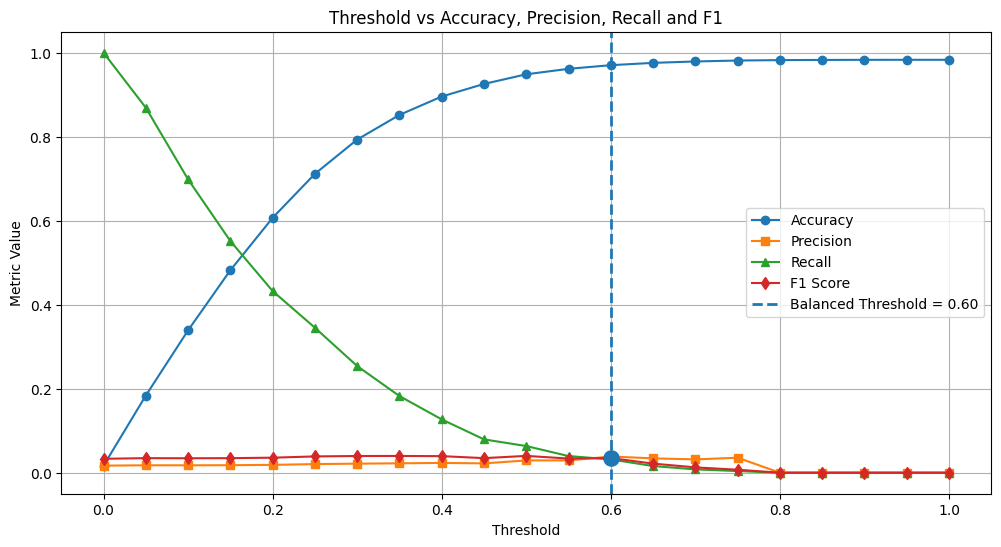

In [21]:
# ==========================================
# THRESHOLD OPTIMIZATION
# ==========================================

thresholds = np.arange(0, 1.01, 0.05)

accuracies = []
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:

    selected = set(
        gene_importance[
            gene_importance["Score"] >= threshold
        ]["Gene"]
    )

    predicted_genes = {
        map_to_main(g)
        for g in selected
    }

    TP_genes = predicted_genes & known_genes
    FP_genes = predicted_genes - known_genes
    FN_genes = known_genes - predicted_genes

    TN_genes = all_genes - (
        TP_genes |
        FP_genes |
        FN_genes
    )

    TP = len(TP_genes)
    FP = len(FP_genes)
    FN = len(FN_genes)
    TN = len(TN_genes)

    accuracy = (
        (TP + TN) /
        (TP + FP + FN + TN)
    )

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0 else 0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0 else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall + 1e-8)
    )

    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

# ==========================================
# FIND BEST BALANCED THRESHOLD
# (IGNORE ZERO VALUES)
# ==========================================

best_idx = None
best_diff = float("inf")

for i in range(1, len(thresholds)-1):

    # Skip thresholds producing zero metrics

    if (
        precisions[i] == 0
        or recalls[i] == 0
        or f1_scores[i] == 0
    ):
        continue

    diff = (
        abs(precisions[i] - recalls[i])
        + abs(precisions[i] - f1_scores[i])
        + abs(recalls[i] - f1_scores[i])
    )

    if diff < best_diff:

        best_diff = diff
        best_idx = i

if best_idx is None:

    print(
        "No threshold found with "
        "non-zero Precision, Recall and F1."
    )

else:

    best_threshold = thresholds[best_idx]

    print("\n==============================")
    print(" BEST BALANCED THRESHOLD")
    print("==============================")

    print(
        f"Threshold : {best_threshold:.2f}"
    )

    print(
        f"Accuracy  : {accuracies[best_idx]:.4f}"
    )

    print(
        f"Precision : {precisions[best_idx]:.4f}"
    )

    print(
        f"Recall    : {recalls[best_idx]:.4f}"
    )

    print(
        f"F1 Score  : {f1_scores[best_idx]:.4f}"
    )

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    thresholds,
    accuracies,
    marker='o',
    label='Accuracy'
)

plt.plot(
    thresholds,
    precisions,
    marker='s',
    label='Precision'
)

plt.plot(
    thresholds,
    recalls,
    marker='^',
    label='Recall'
)

plt.plot(
    thresholds,
    f1_scores,
    marker='d',
    label='F1 Score'
)

if best_idx is not None:

    plt.axvline(
        x=best_threshold,
        linestyle='--',
        linewidth=2,
        label=f'Balanced Threshold = {best_threshold:.2f}'
    )

    plt.scatter(
        best_threshold,
        f1_scores[best_idx],
        s=120,
        zorder=5
    )

plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title(
    "Threshold vs Accuracy, Precision, Recall and F1"
)

plt.grid(True)
plt.legend()

plt.show()